In [201]:
using Pickle, OpenQuantumTools, OrdinaryDiffEq, Plots, PyCall, LinearAlgebra, DelimitedFiles

function lindblad_sim(
    omegaZ::Float64,
    gammaAD::Float64,
    gammaZ::Float64,
    f::Float64,
    u0::Array,
    time::Int,
    length::Int,
)

    σp = [0.0 0.0; 1.0 0.0]
    σm = [0.0 1.0; 0.0 0.0]

    H = DenseHamiltonian([(s) -> omegaZ], [σz])

    lindRe = Lindblad(gammaAD * f, σp)
    lindEx = Lindblad(gammaAD * (1 - f), σm)
    lindZ = Lindblad(gammaZ, σz)

    annealing = Annealing(H, u0, interactions = InteractionSet(lindRe, lindEx, lindZ))

    sol = solve_lindblad(annealing, time, alg = Tsit5())

    t_axis = range(0, time, length = length)
    bloch_vector = []
    for t in t_axis
        push!(bloch_vector, 2 * real.(matrix_decompose(sol(t), [σx, σy, σz])))
    end

    off_diag = []
    for t in t_axis
        push!(off_diag, abs(sol(t)[1, 2]))
    end

    return t_axis, bloch_vector
end

function dm_to_bloch(dm::Array)
    return 2 * real.(matrix_decompose(dm, [σx, σy, σz]))
end


function chi2(sim_bloch, exp_bloch)

    if length(sim_bloch) != length(exp_bloch)
        error("Simulation and experiment have different length.")
    end

    total_diff = 0
    for i = 1:length(sim_bloch)
        curr_diff = 0

        for j = 1:3
            curr_diff += (exp_bloch[i][j] - sim_bloch[i][j])^2
        end

        total_diff += curr_diff
    end

    return total_diff
end


function optimize_params(
    omegaZ_ls,
    gammaAD_ls,
    gammaZ_ls,
    f_ls,
    u0,
    time,
    length,
    exp_data,
)

    sol0 =
        lindblad_sim(omegaZ_ls[1], gammaAD_ls[1], gammaZ_ls[1], f_ls[1], u0, time, length)[2]
    min_diff = chi2(exp_data, sol0)
    opt_params = [omegaZ_ls[1] gammaAD_ls[1] gammaZ_ls[1] f_ls[1]]

    for curr_omegaZ in omegaZ_ls
        for curr_gammaAD in gammaAD_ls
            for curr_gammaZ in gammaZ_ls
                for curr_f in f_ls

                    curr_sol = lindblad_sim(
                        curr_omegaZ,
                        curr_gammaAD,
                        curr_gammaZ,
                        curr_f,
                        u0,
                        time,
                        length,
                    )[2]
                    curr_diff = chi2(exp_data, curr_sol)

                    if curr_diff < min_diff
                        min_diff = curr_diff
                        opt_params = [curr_omegaZ curr_gammaAD curr_gammaZ curr_f]
                    end

                end
            end
        end
    end

    return opt_params
end


function plot_bloch(bloch_vector)
    plot(t_axis, [c[1] for c in bloch_vector], label="X", linewidth=2)
    plot!(t_axis, [c[2] for c in bloch_vector], label="Y", linewidth=2)
    plot!(t_axis, [c[3] for c in bloch_vector], label="Z", linewidth=2)
    xlabel!("t (ns)")
    ylabel!("Bloch Vector")
end


py"""
import pickle
 
def load_pickle(fpath):
    with open(fpath, "rb") as f:
        data = pickle.load(f)
    return data
"""

load_pickle = py"load_pickle"

moving_average(vs,n) = [sum(@view vs[i:(i+n-1)])/n for i in 1:(length(vs)-(n-1))]

moving_average (generic function with 1 method)

In [193]:
exp_dm = load_pickle("/Users/wangchengyu/Code/QC/550_final/np_plus_state_tomography_single.pickle");
exp_dm_mit = load_pickle("/Users/wangchengyu/Code/QC/550_final/np_plus_mitigated_state_tomography_single.pickle");
exp_dm_minus = load_pickle("/Users/wangchengyu/Code/QC/550_final/np_minus_state_tomography_single.pickle");
exp_dm_i = load_pickle("/Users/wangchengyu/Code/QC/550_final/np_plus_i_state_tomography_single.pickle");
exp_dm_mi = load_pickle("/Users/wangchengyu/Code/QC/550_final/np_minus_i_state_tomography_single.pickle");
dN = load_pickle("/Users/wangchengyu/Code/QC/550_final/1q_dN.pickle");
dN2 = load_pickle("/Users/wangchengyu/Code/QC/550_final/1q_dN2.pickle");
dN2z = load_pickle("/Users/wangchengyu/Code/QC/550_final/1q_dN2z.pickle");

In [39]:
exp_bloch = []
for i in 1:length(exp_dm)
    push!(exp_bloch, dm_to_bloch(exp_dm[i]))
end

3-element Vector{Vector{Float64}}:
 [0.7967000000000001, 0.7771, 0.7555000000000001, 0.7419, 0.6583, 0.6299, 0.6436, 0.5399, 0.4951, 0.46099999999999997  …  0.02899999999999998, 0.0341, 0.007199999999999984, -0.017300000000000003, -0.06620000000000001, -0.0786, -0.04860000000000001, -0.03130000000000001, -0.020600000000000018, 0.035899999999999974]
 [-0.10789999999999997, -0.17109999999999997, -0.14619999999999997, -0.18359999999999999, -0.2561, -0.3186, -0.2585, -0.39089999999999997, -0.43, -0.3334  …  -0.016100000000000003, -0.006800000000000006, -0.002100000000000002, 0.019200000000000005, 0.04239999999999999, 0.0137, -0.0028999999999999916, 0.029200000000000014, -0.02799999999999999, -0.029099999999999994]
 [0.08859999999999993, 0.09009999999999992, 0.13129999999999983, 0.14079999999999981, 0.1287999999999998, 0.13849999999999985, 0.13219999999999982, 0.12399999999999985, 0.1044999999999999, 0.11129999999999991  …  0.5426999999999994, 0.44199999999999956, 0.4780999999999995, 0.5191

In [126]:
exp_bloch_mit = []
for i in 1:length(exp_dm_mit)
    push!(exp_bloch_mit, dm_to_bloch(exp_dm_mit[i]))
end

In [128]:
exp_bloch_minus = []
for i in 1:length(exp_dm_minus)
    push!(exp_bloch_minus, dm_to_bloch(exp_dm_minus[i]))
end

In [137]:
exp_bloch_i = []
for i in 1:length(exp_dm_i)
    push!(exp_bloch_i, dm_to_bloch(exp_dm_i[i]))
end

In [138]:
exp_bloch_mi = []
for i in 1:length(exp_dm_mi)
    push!(exp_bloch_mi, dm_to_bloch(exp_dm_mi[i]))
end

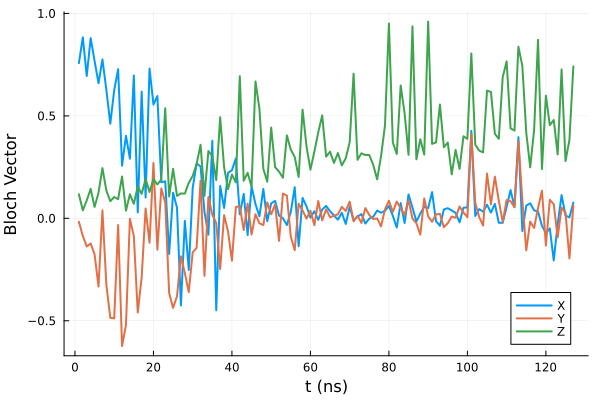

In [44]:
t_axis = range(1, 127)
plot(t_axis, [c[1] for c in exp_bloch], label="X", linewidth=2)
plot!(t_axis, [c[2] for c in exp_bloch], label="Y", linewidth=2)
plot!(t_axis, [c[3] for c in exp_bloch], label="Z", linewidth=2)
xlabel!("t (ns)")
ylabel!("Bloch Vector")

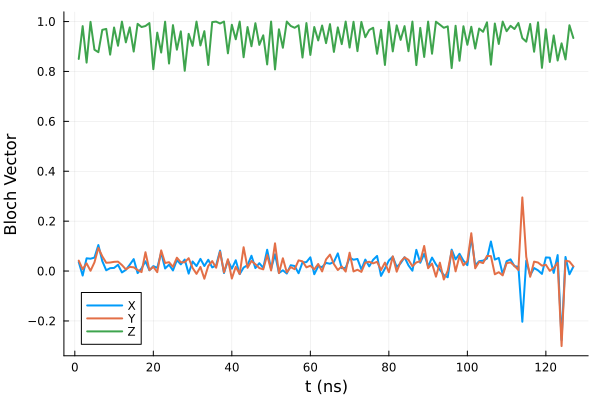

In [127]:
t_axis = range(1, 127)
plot(t_axis, [c[1] for c in exp_bloch_mit], label="X", linewidth=2)
plot!(t_axis, [c[2] for c in exp_bloch_mit], label="Y", linewidth=2)
plot!(t_axis, [c[3] for c in exp_bloch_mit], label="Z", linewidth=2)
xlabel!("t (ns)")
ylabel!("Bloch Vector")

In [ ]:
omegaZ = 0.00001
gammaAD = 0.00002
gammaZ = 0.00003
f = 0.2

In [70]:
omegaZ_ls = range(0.000005, 0.000014, 10);
gammaAD_ls = range(0.000015, 0.000024, 10);
gammaZ_ls = range(0.000025, 0.000034, 10);
f_ls = range(0.1, 0.5, 5)

0.1:0.1:0.5

In [103]:
params = optimize_params(
    omegaZ_ls,
    gammaAD_ls,
    gammaZ_ls,
    f_ls,
    1 / 2 * [1.0 1.0; 1.0 1.0],
    127000,
    127,
    exp_bloch
)

1×4 Matrix{Float64}:
 5.0e-6  1.7e-5  3.4e-5  0.2

In [143]:
sol_opt = lindblad_sim(params[1], params[2], params[3], params[4], 1 / 2 * [1.0 1.0; 1.0 1.0], 127000, 127)[2]
plot(t_axis, [c[1] for c in sol_opt], label="L-ME X", linewidth=2, dpi=400)
plot!(t_axis, [c[2] for c in sol_opt], label="L-ME Y", linewidth=2)
plot!(t_axis, [c[3] for c in sol_opt], label="L-ME Z", linewidth=2)
t_axis = range(1, 127)
scatter!(t_axis, [c[1] for c in exp_bloch], label="exp X", linewidth=2)
scatter!(t_axis, [c[2] for c in exp_bloch], label="exp Y", linewidth=2)
scatter!(t_axis, [c[3] for c in exp_bloch], label="exp Z", linewidth=2)
xlabel!("t (μs)")
ylabel!("Bloch Vector")
savefig("opt_plus.png")

"/Users/wangchengyu/Code/QC/550_final/lindblad_julia/opt_plus.png"

In [159]:
diff_bloch = []
for i in 1:length(sol_opt)
    push!(diff_bloch, norm(sol_opt[i] - exp_bloch[i]))
end

diff_bloch_minus = []
for i in 1:length(sol_opt_minus)
    push!(diff_bloch_minus, norm(sol_opt_minus[i] - exp_bloch_minus[i]))
end

diff_bloch_i = []
for i in 1:length(sol_opt_i)
    push!(diff_bloch_i, norm(sol_opt_i[i] - exp_bloch_i[i]))
end

diff_bloch_mi = []
for i in 1:length(sol_opt_mi)
    push!(diff_bloch_mi, norm(sol_opt_mi[i] - exp_bloch_mi[i]))
end

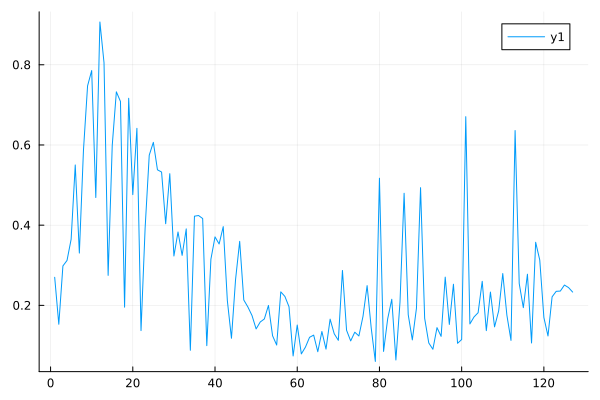

In [111]:
plot(t_axis, diff_bloch)

In [144]:
sol_opt_minus = lindblad_sim(params[1], params[2], params[3], params[4], 1 / 2 * [1.0 -1.0; -1.0 1.0], 127000, 127)[2]
t_axis = range(1, 127)
plot(t_axis, [c[1] for c in sol_opt_minus], label="L-ME X", linewidth=2, dpi=400)
plot!(t_axis, [c[2] for c in sol_opt_minus], label="L-ME Y", linewidth=2)
plot!(t_axis, [c[3] for c in sol_opt_minus], label="L-ME Z", linewidth=2)
scatter!(t_axis, [c[1] for c in exp_bloch_minus], label="exp X", linewidth=2)
scatter!(t_axis, [c[2] for c in exp_bloch_minus], label="exp Y", linewidth=2)
scatter!(t_axis, [c[3] for c in exp_bloch_minus], label="exp Z", linewidth=2)
xlabel!("t (μs)")
ylabel!("Bloch Vector")
savefig("opt_minus.png")

"/Users/wangchengyu/Code/QC/550_final/lindblad_julia/opt_minus.png"

In [145]:
sol_opt_i = lindblad_sim(params[1], params[2], params[3], params[4], 1 / 2 * [1.0 -1.0im; 1.0im 1.0], 127000, 127)[2]
t_axis = range(1, 127)
plot(t_axis, [c[1] for c in sol_opt_i], label="L-ME X", linewidth=2, dpi=400)
plot!(t_axis, [c[2] for c in sol_opt_i], label="L-ME Y", linewidth=2)
plot!(t_axis, [c[3] for c in sol_opt_i], label="L-ME Z", linewidth=2)
scatter!(t_axis, [c[1] for c in exp_bloch_i], label="exp X", linewidth=2)
scatter!(t_axis, [c[2] for c in exp_bloch_i], label="exp Y", linewidth=2)
scatter!(t_axis, [c[3] for c in exp_bloch_i], label="exp Z", linewidth=2)
xlabel!("t (μs)")
ylabel!("Bloch Vector")
savefig("opt_plusi.png")

"/Users/wangchengyu/Code/QC/550_final/lindblad_julia/opt_plusi.png"

In [146]:
sol_opt_mi = lindblad_sim(params[1], params[2], params[3], params[4], 1 / 2 * [1.0 1.0im; -1.0im 1.0], 127000, 127)[2]
t_axis = range(1, 127)
plot(t_axis, [c[1] for c in sol_opt_mi], label="L-ME X", linewidth=2, dpi=400)
plot!(t_axis, [c[2] for c in sol_opt_mi], label="L-ME Y", linewidth=2)
plot!(t_axis, [c[3] for c in sol_opt_mi], label="L-ME Z", linewidth=2)
scatter!(t_axis, [c[1] for c in exp_bloch_mi], label="exp X", linewidth=2)
scatter!(t_axis, [c[2] for c in exp_bloch_mi], label="exp Y", linewidth=2)
scatter!(t_axis, [c[3] for c in exp_bloch_mi], label="exp Z", linewidth=2)
xlabel!("t (μs)")
ylabel!("Bloch Vector")
savefig("opt_minusi.png")

"/Users/wangchengyu/Code/QC/550_final/lindblad_julia/opt_minusi.png"

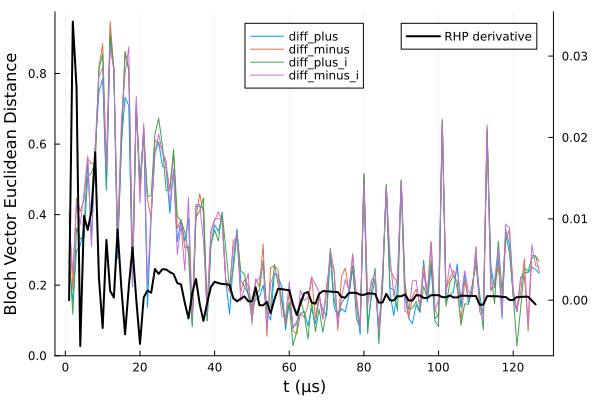

In [178]:
# plot(dN * 100)
# plot!(diff_bloch)

plot(diff_bloch,label="diff_plus",legend=:top)
plot!(diff_bloch_minus,label="diff_minus",legend=:top)
plot!(diff_bloch_i,label="diff_plus_i",legend=:top)
plot!(diff_bloch_mi,label="diff_minus_i",legend=:top)
xlabel!("t (μs)")
ylabel!("Bloch Vector Euclidean Distance")
plot!(twinx(),dN,color=:black,xticks=:none,label="RHP derivative", linewidth=2)
# savefig("diff_rhp.png")



In [198]:
plot(diff_bloch,label="diff_plus",legend=:top)
plot!(diff_bloch_minus,label="diff_minus",legend=:top)
plot!(diff_bloch_i,label="diff_plus_i",legend=:top)
plot!(diff_bloch_mi,label="diff_minus_i",legend=:top)
xlabel!("t (μs)")
ylabel!("Bloch Vector Euclidean Distance")
plot!(twinx(),dN2,color=:black,xticks=:none,label="I-B based dN X-basis", linewidth=2)
savefig("diff_IFX.png")

"/Users/wangchengyu/Code/QC/550_final/lindblad_julia/diff_IFX.png"

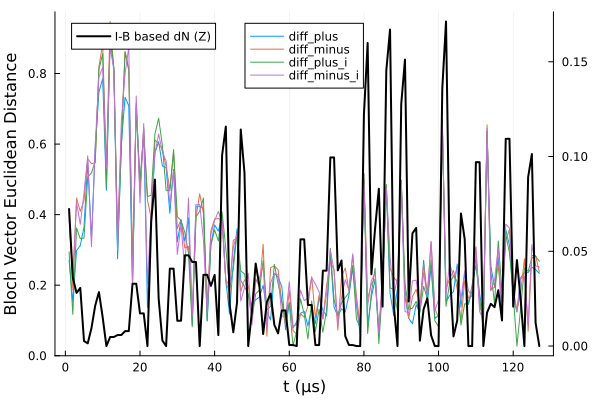

In [194]:
plot(diff_bloch,label="diff_plus",legend=:top)
plot!(diff_bloch_minus,label="diff_minus",legend=:top)
plot!(diff_bloch_i,label="diff_plus_i",legend=:top)
plot!(diff_bloch_mi,label="diff_minus_i",legend=:top)
xlabel!("t (μs)")
ylabel!("Bloch Vector Euclidean Distance")
plot!(twinx(),dN2z,color=:black,xticks=:none,label="I-B based dN (Z)", linewidth=2)

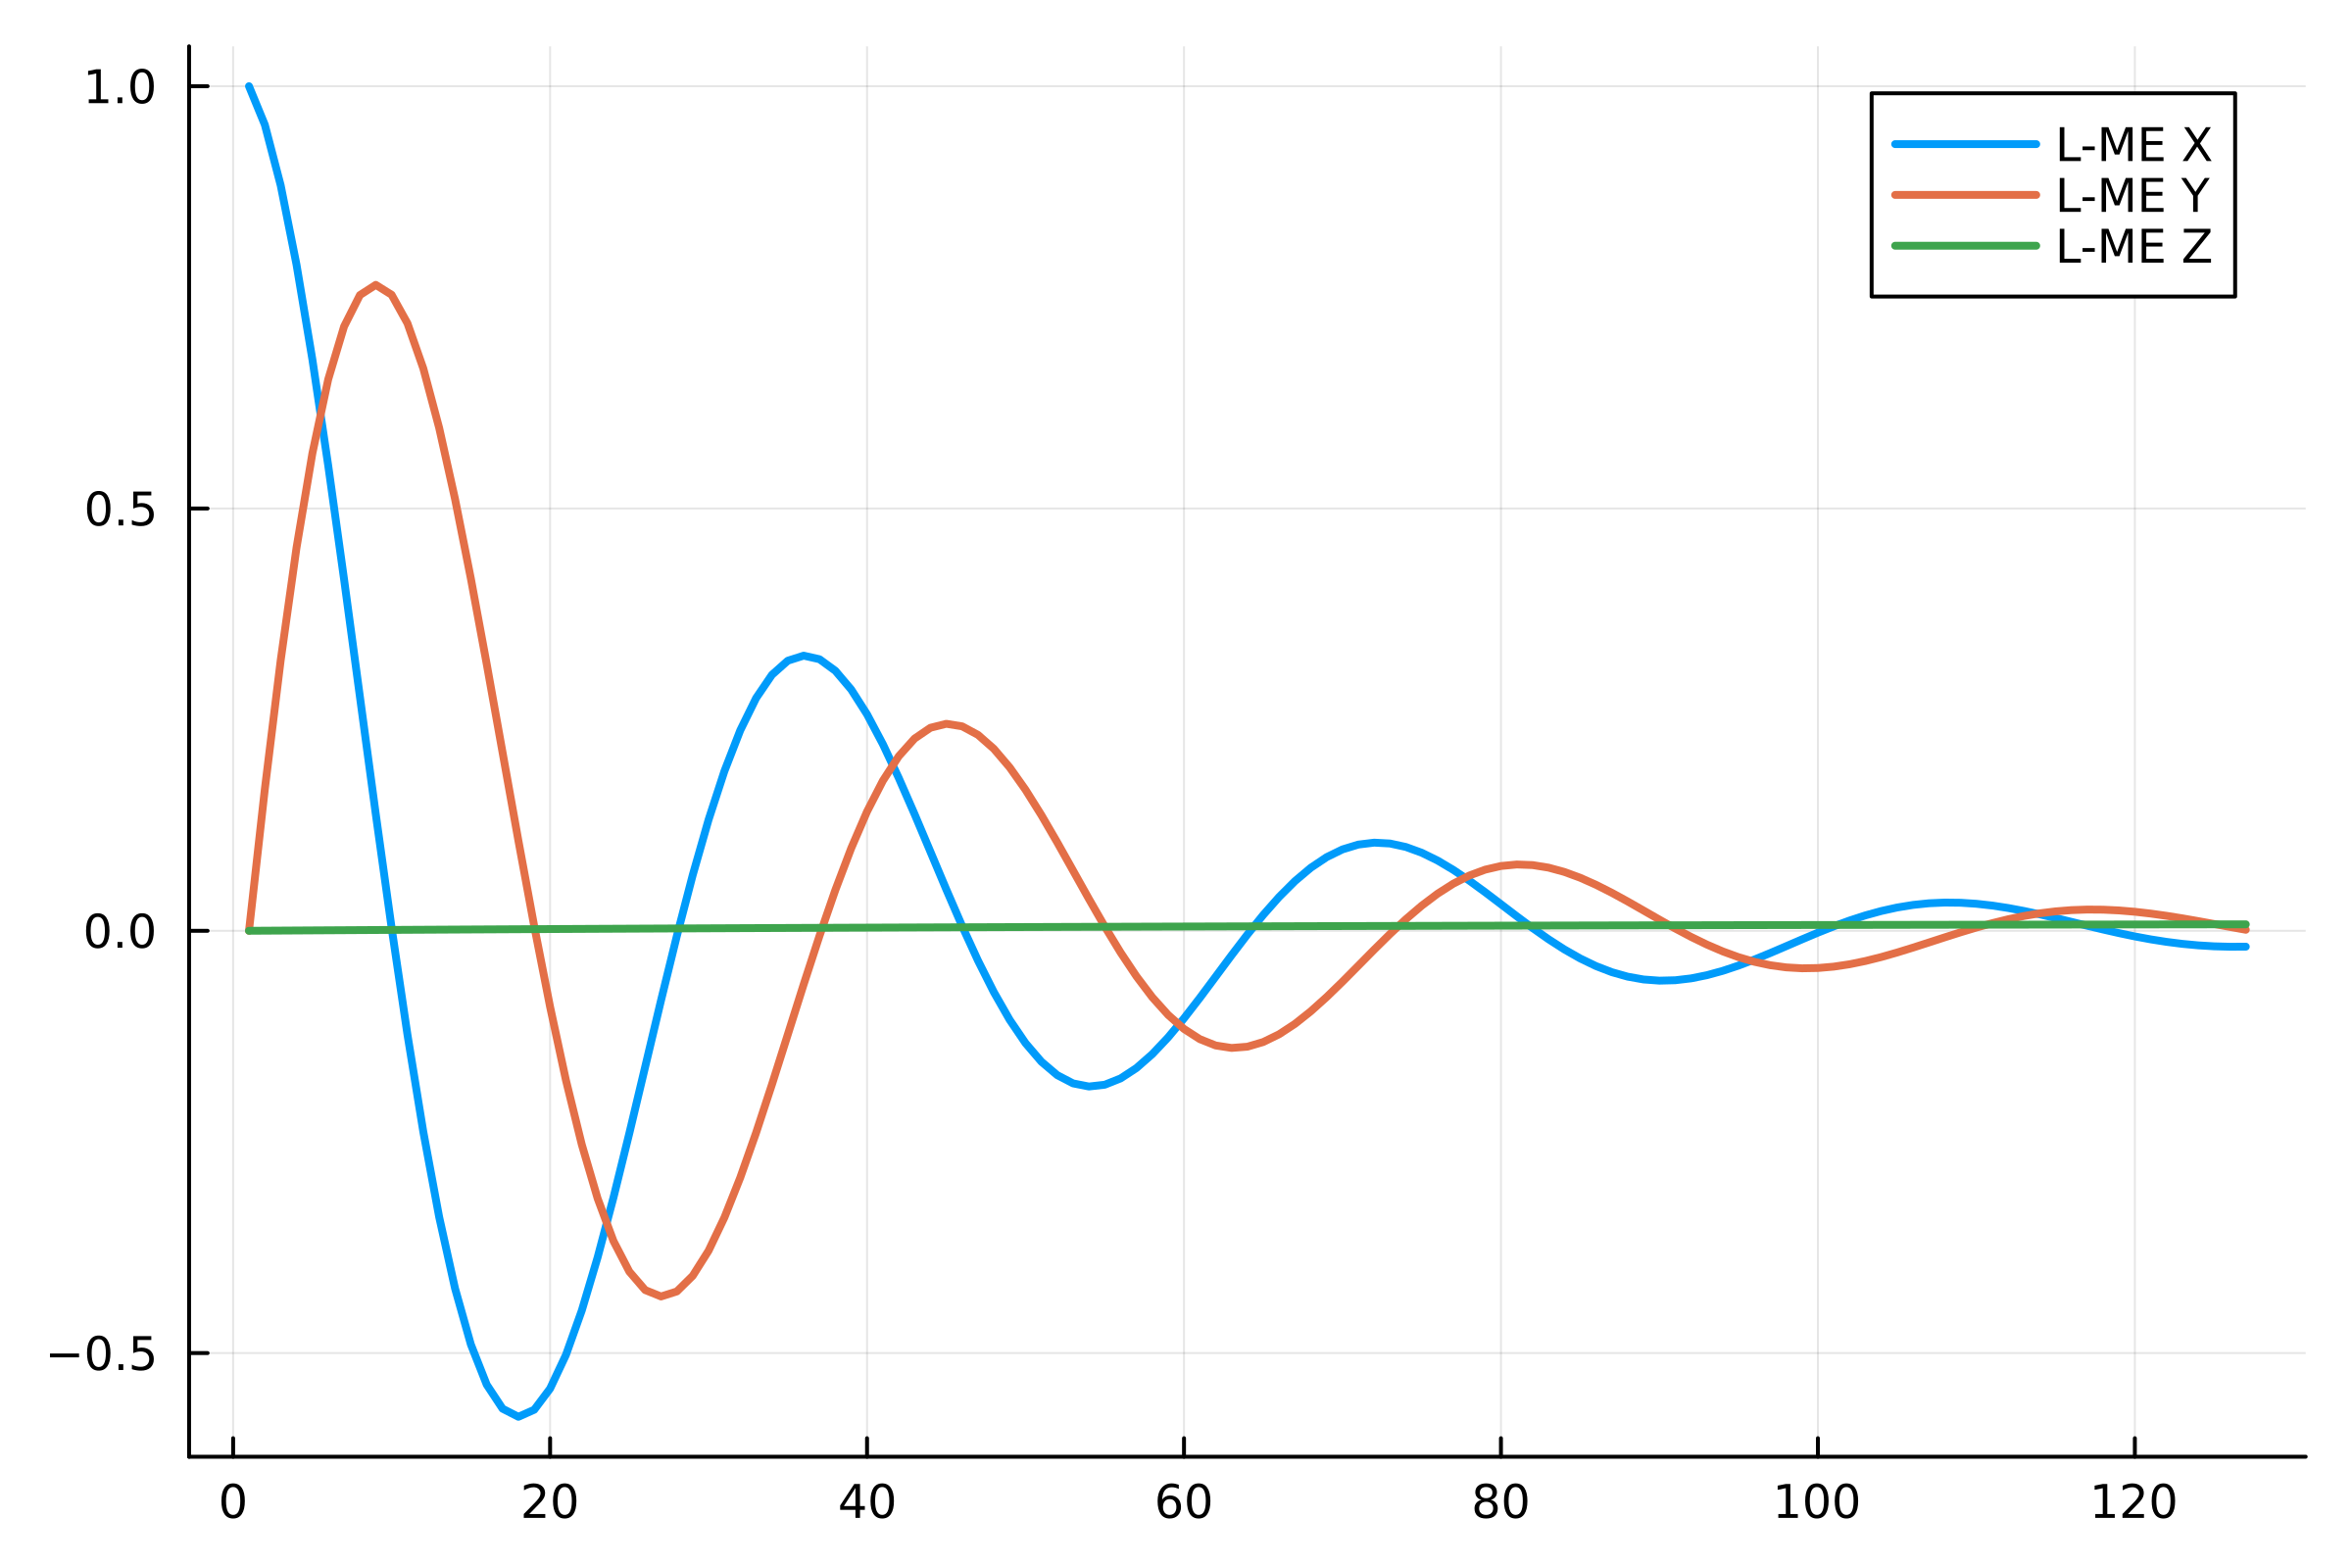

In [191]:
sol2 = lindblad_sim(0.08723995, 0.07919411, 0.07945966, 0.49518312, 1 / 2 * [1.0 1.0; 1.0 1.0], 20, 127)[2]
plot(t_axis, [c[1] for c in sol2], label="L-ME X", linewidth=2, dpi=400)
plot!(t_axis, [c[2] for c in sol2], label="L-ME Y", linewidth=2)
plot!(t_axis, [c[3] for c in sol2], label="L-ME Z", linewidth=2)

In [204]:
writedlm("sol_opt.csv", sol_opt, ',')